In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('visa_approval_data.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [39]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (25480, 12)


In [40]:
print("Datatypes of the columns:\n", df.dtypes)

Datatypes of the columns:
 case_id                      str
continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
yr_of_estab                int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
dtype: object


In [41]:
print("Statistical summary of the dataset:\n", df.describe())

Statistical summary of the dataset:
        no_of_employees   yr_of_estab  prevailing_wage
count     25480.000000  25480.000000     25480.000000
mean       5667.043210   1979.409929     74455.814592
std       22877.928848     42.366929     52815.942327
min         -26.000000   1800.000000         2.136700
25%        1022.000000   1976.000000     34015.480000
50%        2109.000000   1997.000000     70308.210000
75%        3504.000000   2005.000000    107735.512500
max      602069.000000   2016.000000    319210.270000


In [42]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

Missing values in each column:
 case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


# Exploratory Data Analysis

In [44]:
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"We have {len(numeric_columns)} numeric columns: {numeric_columns}")
print(f"We have {len(categorical_columns)} categorical columns: {categorical_columns}")

We have 3 numeric columns: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
We have 9 categorical columns: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [45]:
for column in categorical_columns:
    print(df[column].value_counts(normalize=True) * 100)

case_id
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
EZYV05       0.003925
               ...   
EZYV25476    0.003925
EZYV25477    0.003925
EZYV25478    0.003925
EZYV25479    0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
region_of_employment
Northeast    28.237834
South        27.539246
West         25.847724
Midwest      16.903454
Island        1.471743
Name: proportion, dtype: float64
unit_o

### Insights
`case_id` have unique values for each column which can be dropped as it is redundant.

`continent` column is highly biased towards asia. hence we can combine other categories to form a single category.

`unit_of_wage` seems to be an important column as most of them are yearly contracts.

# Univariate Analysis

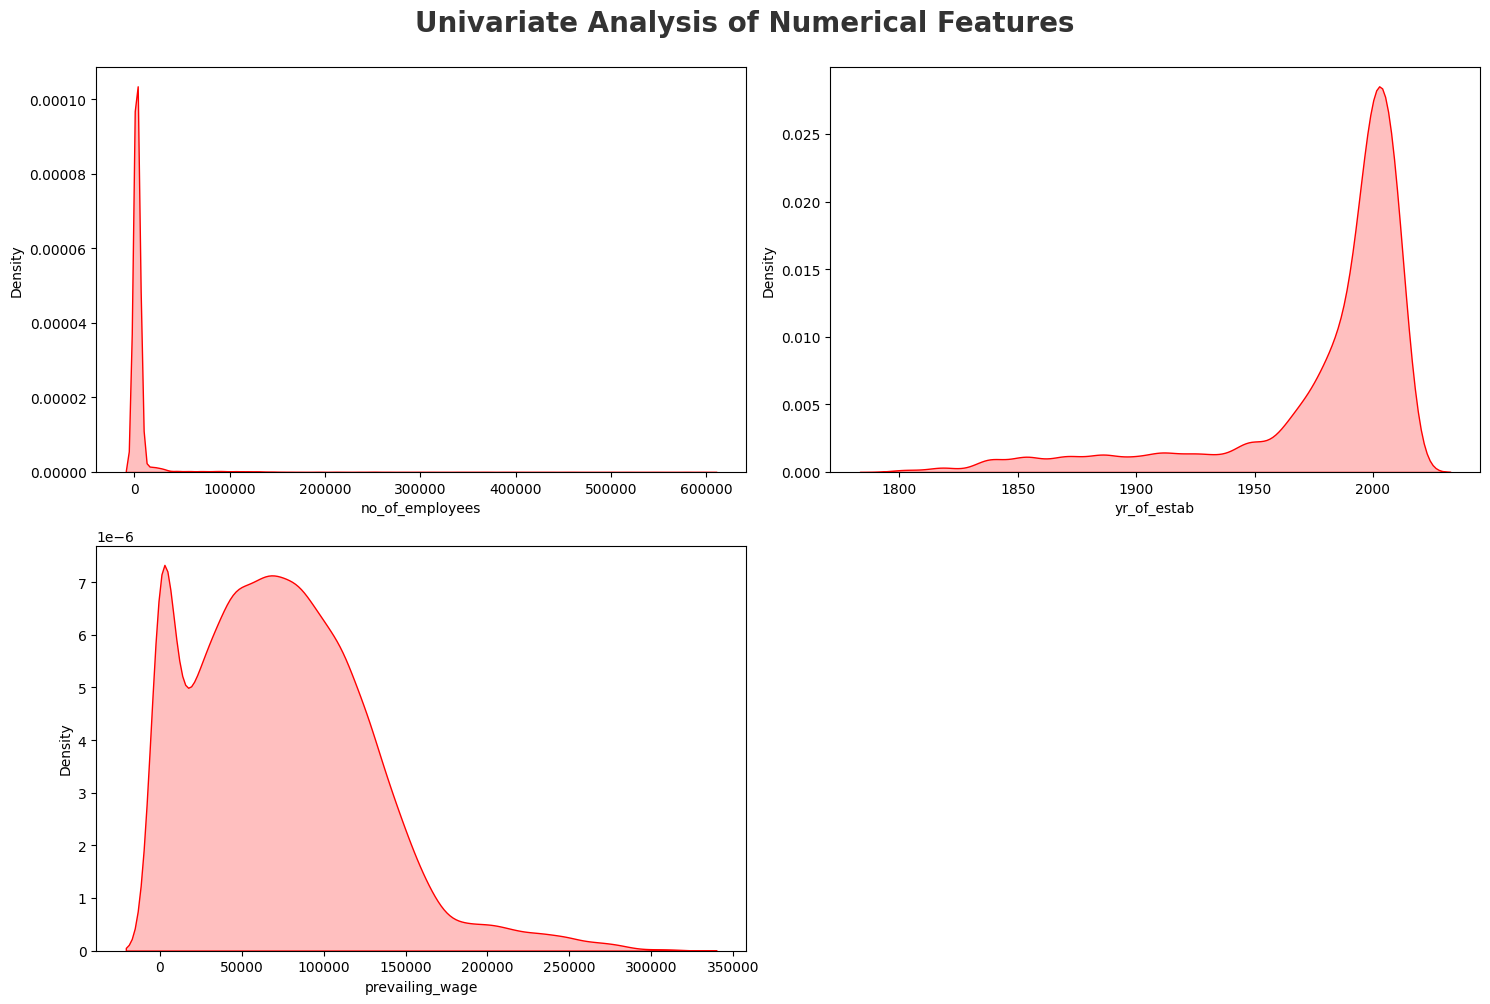

In [46]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_columns)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_columns[i]], color='red', fill=True)
    plt.xlabel(numeric_columns[i])
    plt.tight_layout()

### Insight
`no_of_employees` column looks more skewed but it may be because of outliers.

`yr_of_estab` is a discrete feature.

`privailing-wage` is a right-skewed distribution.

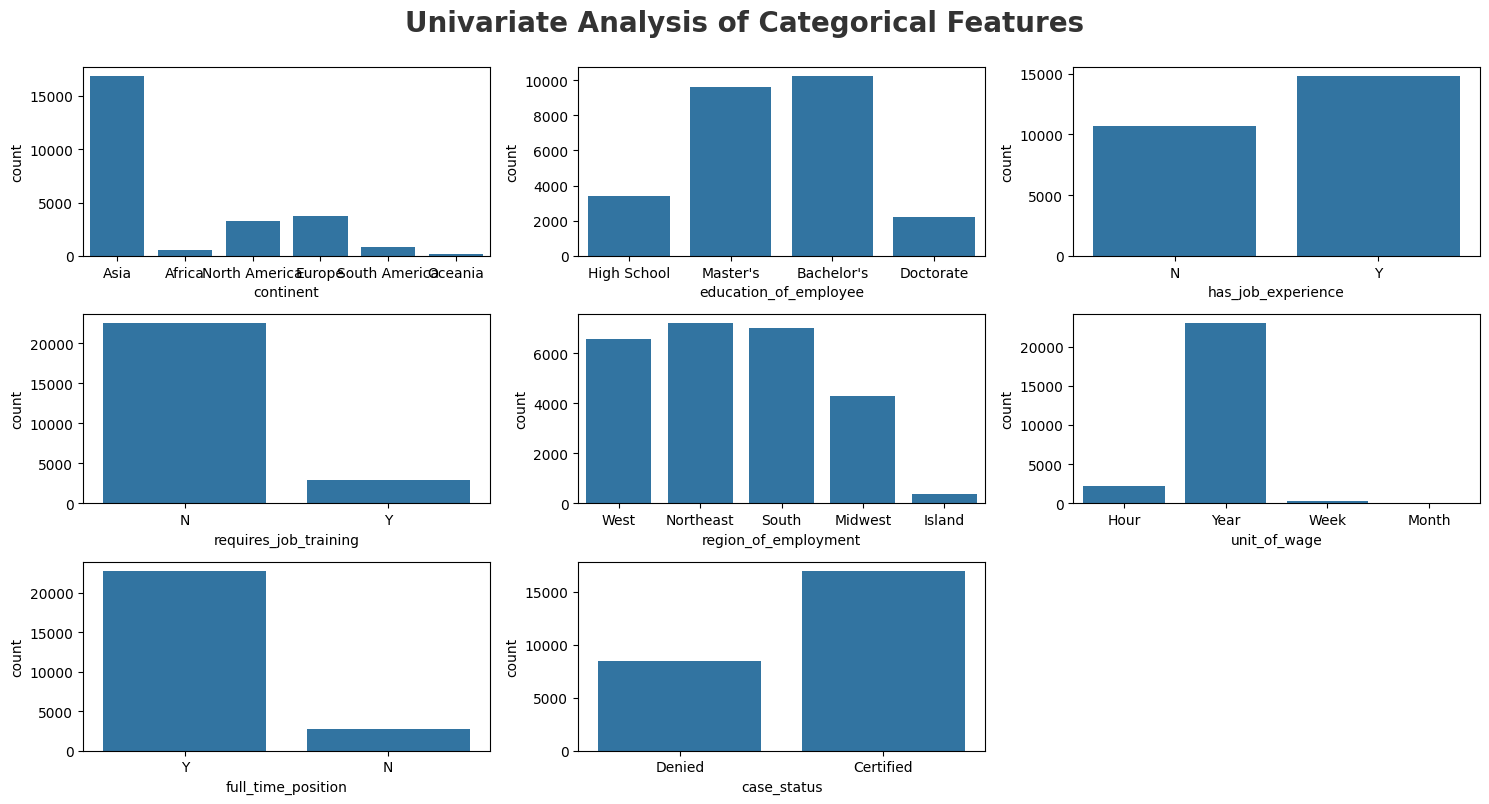

In [47]:
# categorical columns
categorical_columns.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_columns)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_columns[i]])
    plt.xlabel(categorical_columns[i])
    plt.tight_layout()

### Insights
`requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` columns have single category dominating.
In rest of the columns are balanced.

# Multivariate Analysis

In [48]:
discrete_features=[feature for feature in numeric_columns if len(df[feature].unique())<=25]
continuous_features=[feature for feature in numeric_columns if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [49]:
# Checking Multicollinearity
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### Insights

There is no multicollinearity between any variables

**Check Multicollinearity for Categorical features**
* A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test

* A chi-square statistic is one way to show a relationship between two categorical variables.

* Here we test correlation of Categorical columns with Target column i.e case_status

Null Hypothesis ($H_0$): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis ($H_1$): The Feature and Target column are not independent (Correlated)

In [50]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_columns:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_columns, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


### Insight
`requires_job_training` fails to Rejects Null Hypothesis which means it doesn't correlate with target column.

In [51]:
continuous_features=[feature for feature in numeric_columns if len(df[feature].unique())>=10]
print('Num of continues features :',continuous_features)

Num of continues features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


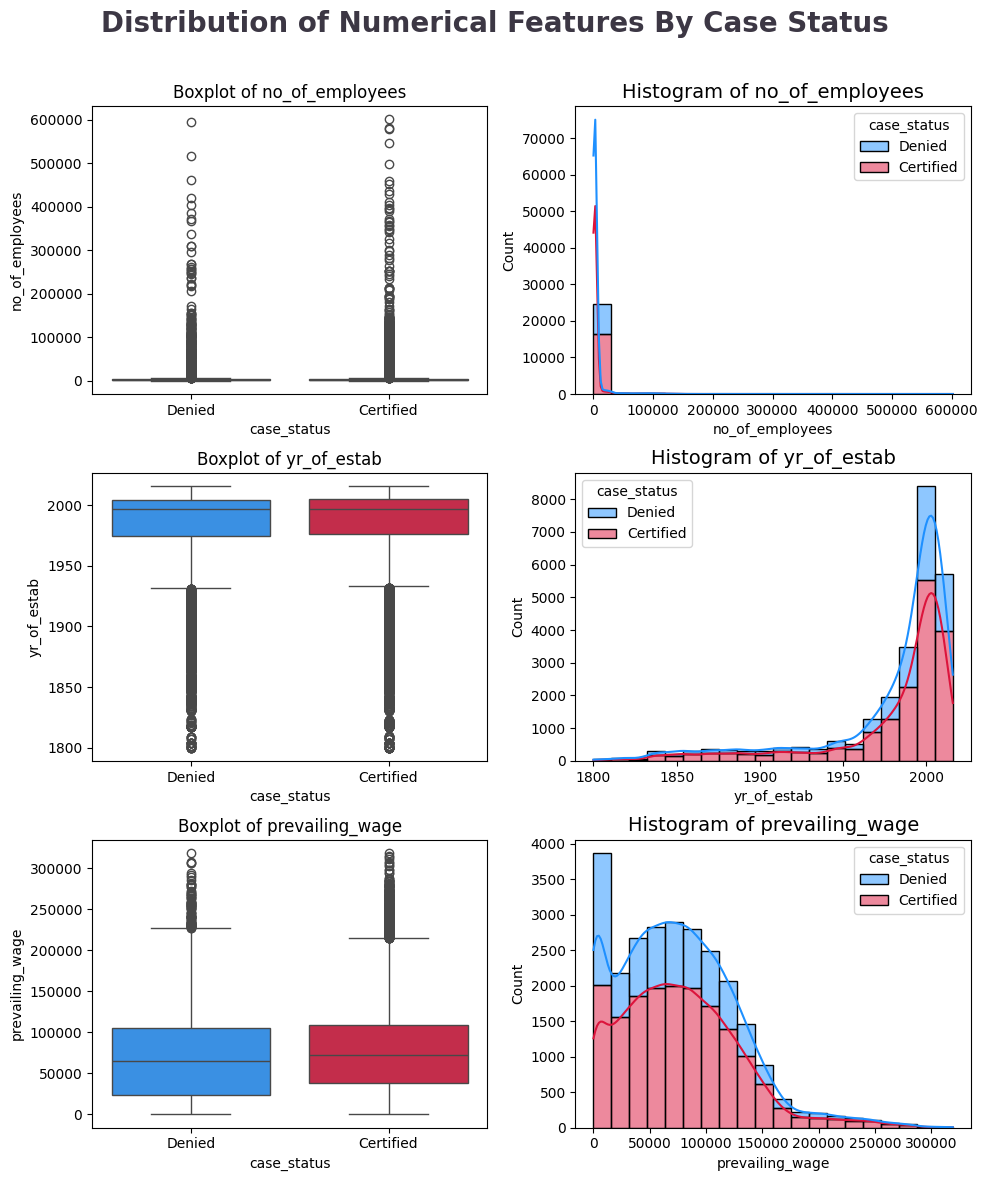

In [52]:
colors = ['#1E90FF', '#DC143C']
fig, ax = plt.subplots(3, 2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By Case Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center')
for i, col in enumerate(continuous_features):   
    sns.boxplot(data=df, x='case_status', y=col,  palette=colors, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=colors, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)

### Insights
`no_of_Employees` has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.

`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.

`prevailing_wage` is right skewed with outliers above upper bound of box plot.

There are No missing values in the dataset.

The `case_id` column can be deleted because each row has unique values.

The `case_status` column is the target to predict.

In the Categorical column, features can be made Binary numerical in feature Encoding

# Visualization of target feature

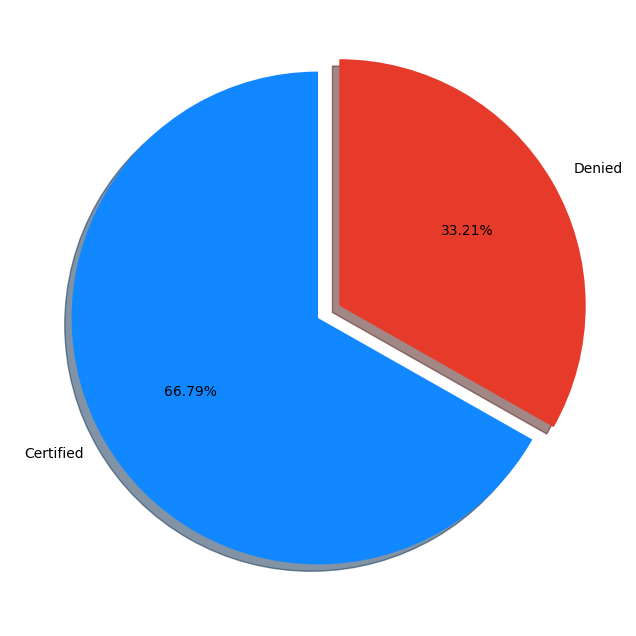

In [53]:
percentage = df.case_status.value_counts(normalize=True)*100
labels = ["Certified","Denied"]

# Plot PieChart with Ploty library
fig, ax = plt.subplots(figsize =(15, 8))
explode = (0, 0.1)
colors = ['#1188ff','#e63a2a']
ax.pie(percentage, labels = labels, startangle = 90,
       autopct='%1.2f%%',explode=explode, shadow=True, colors=colors)
plt.show()

**From the chart it is seen that the Target Variable is Imbalanced** 

What is imbalanced data?

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

In [54]:
# Does applicant Continent has any impact on Visa status ?
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

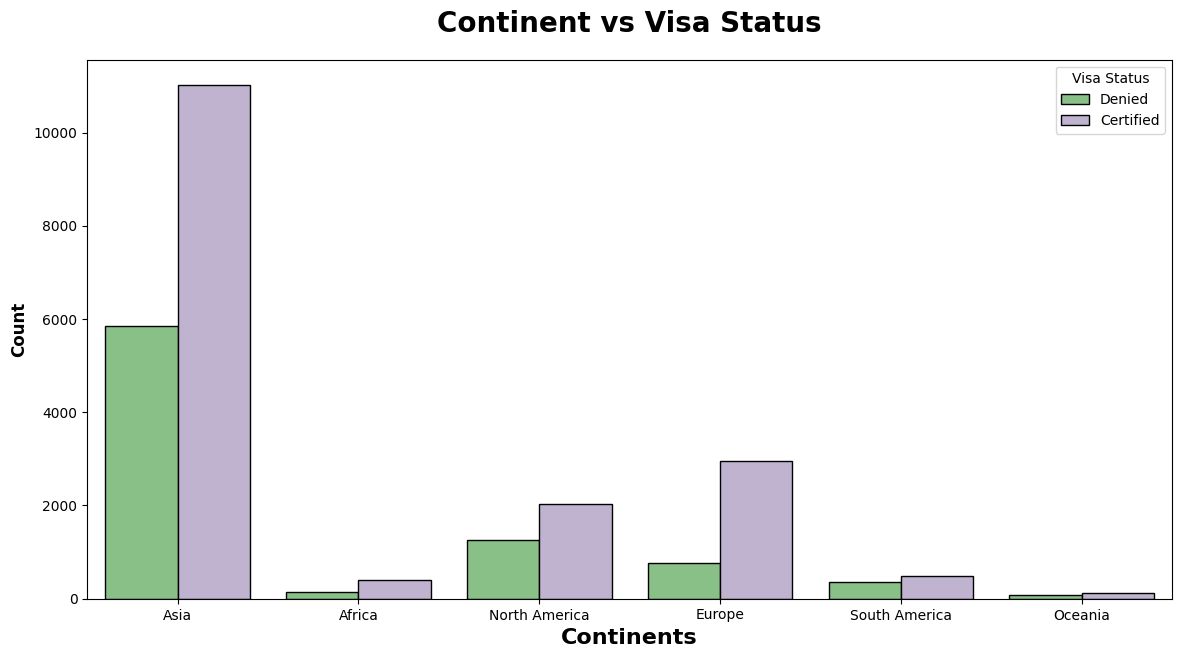

In [55]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continents", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

In [56]:
new_df = df.copy()

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Asia'),
  Text(1, 0, 'Europe'),
  Text(2, 0, 'North America'),
  Text(3, 0, 'South America'),
  Text(4, 0, 'Africa'),
  Text(5, 0, 'Oceania')])

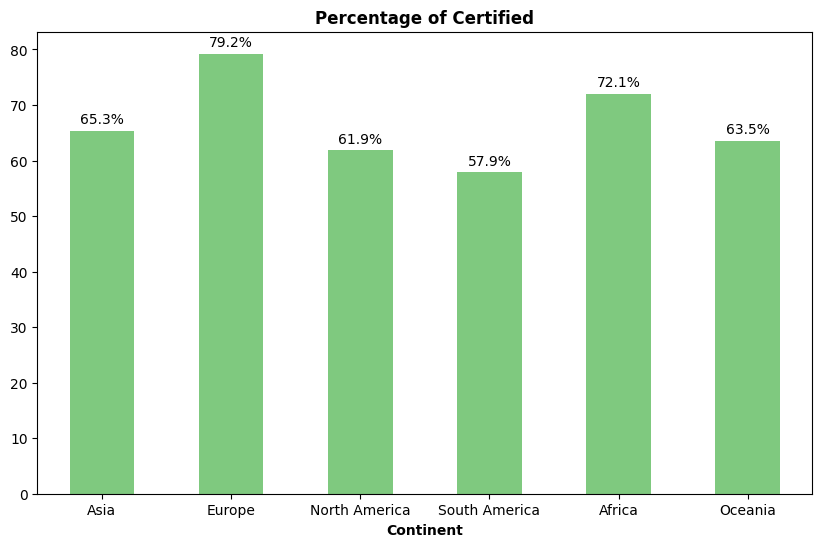

In [63]:
# 1. Calculate the percentages ONCE and store in a variable
certified_counts = new_df[new_df["case_status"] == 'Certified']['continent'].value_counts()
total_counts = new_df['continent'].value_counts()
pct_certified = (certified_counts / total_counts * 100).dropna()
plt.figure(figsize=(10, 6))

# 2. Plot the data and assign it to an axes object ('ax')
ax = pct_certified.plot(kind='bar', colormap='Accent')

# 3. Add labels automatically using modern Matplotlib
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# 4. Apply formatting
plt.title("Percentage of Certified", fontsize=12, fontweight='bold')
plt.xlabel('Continent', fontweight='bold')
plt.xticks(rotation=0)



In [64]:
# Does applicant education has any impact on Visa status ?
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

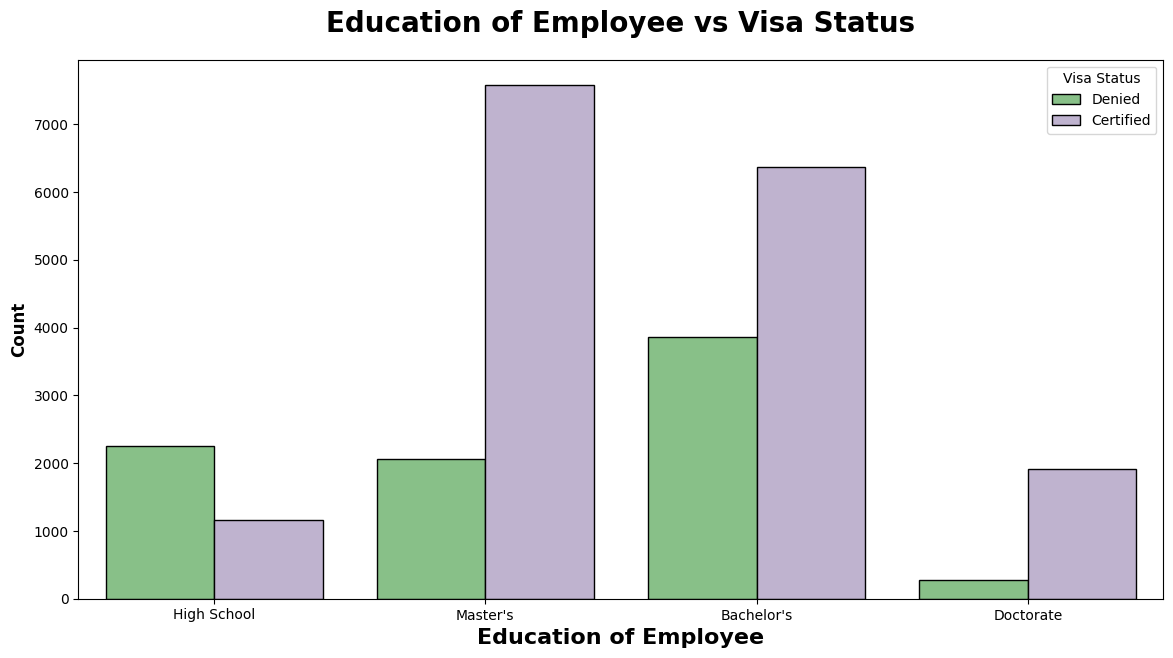

In [65]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Education of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

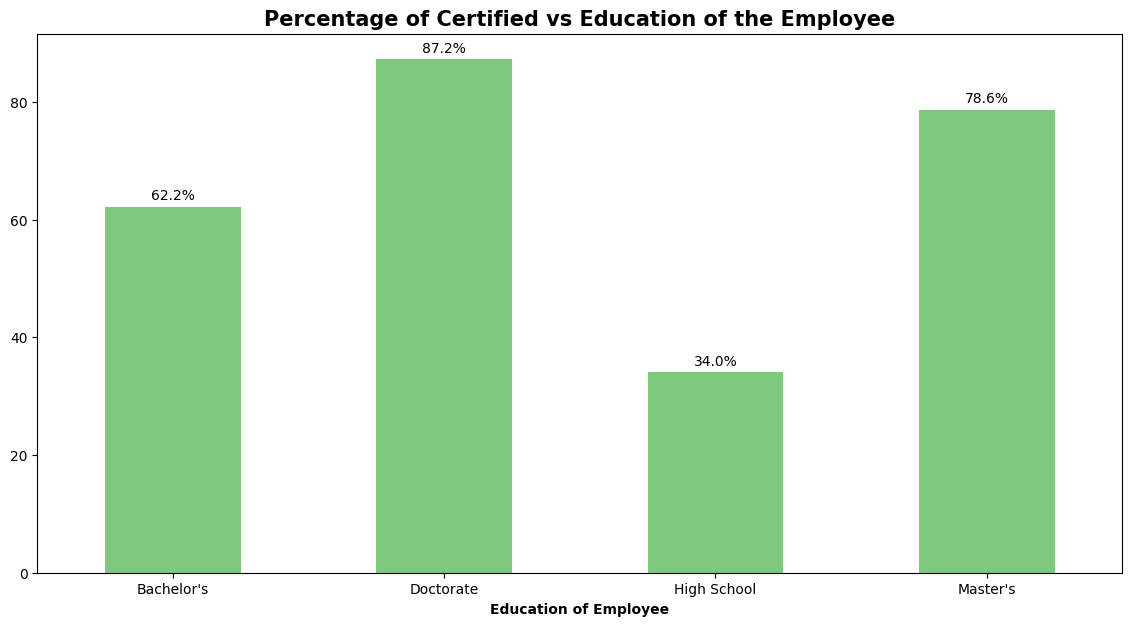

In [70]:
is_certified = new_df['case_status'] == 'Certified'
cert_pct = is_certified.groupby(new_df['education_of_employee']).mean() * 100

plt.figure(figsize=[14, 7])

ax = cert_pct.plot(kind='bar', colormap='Accent')

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

plt.title("Percentage of Certified vs Education of the Employee", fontsize=15, fontweight='bold')
plt.xlabel('Education of Employee', fontweight='bold')
plt.xticks(rotation=0)

plt.show()

### Insights
* Education status has high impact
* Doctorate and Master's graduates have higher rate of being accepted then the others.

In [71]:
# Does applicant's previous work experience has any impact on Visa status ?
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

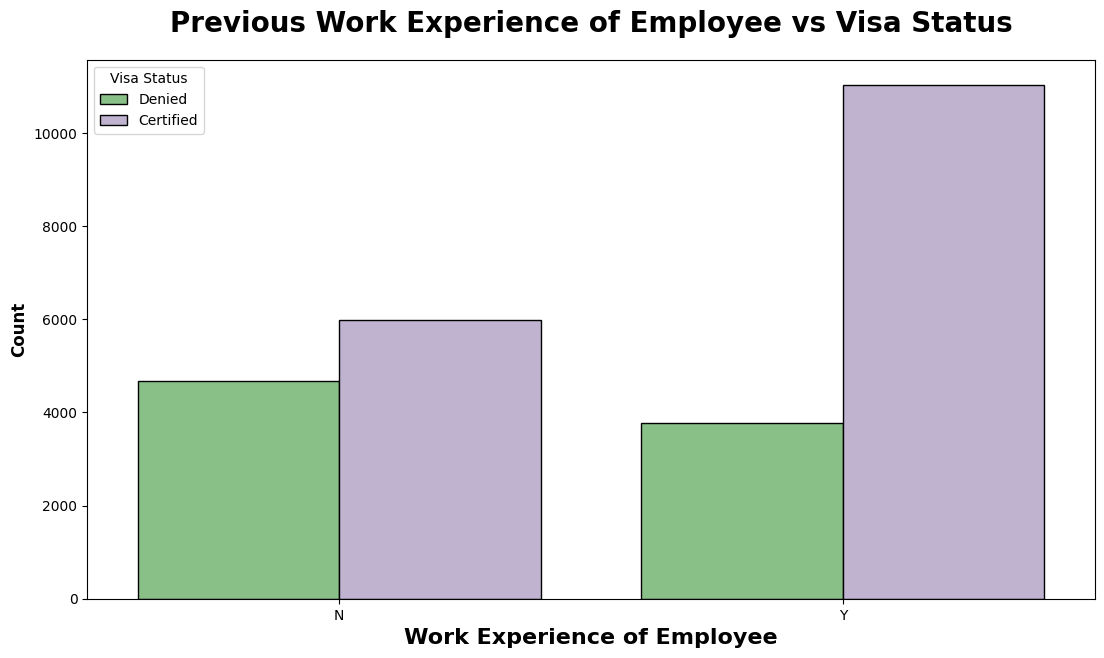

In [72]:
plt.subplots(figsize=(13,7))
sns.countplot(x="has_job_experience",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Previous Work Experience of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Work Experience of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

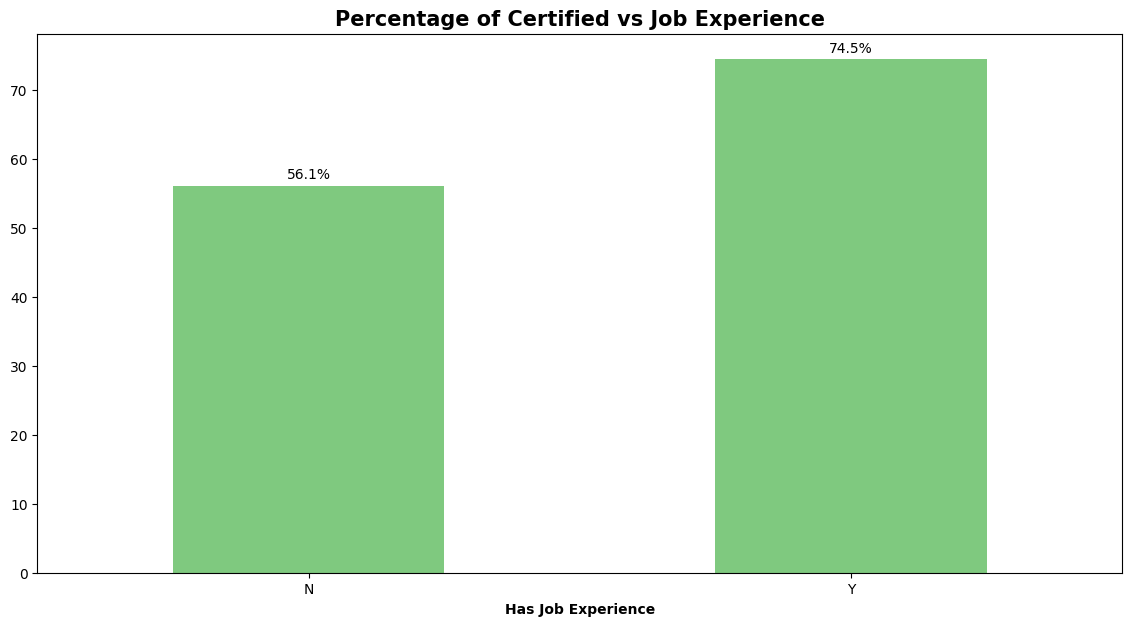

In [73]:
percentages = (new_df['case_status'] == 'Certified').groupby(new_df['has_job_experience']).mean() * 100

ax = percentages.plot(kind='bar', figsize=(14, 7), colormap='Accent')

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

plt.title("Percentage of Certified vs Job Experience", fontsize=15, fontweight='bold')
plt.xlabel('Has Job Experience', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### Insight
* People with previous work experience has been certified 74.5% only 25.5% applicant has been denied.
* People with No previous work experience has been certified 56% and denied 43%.
* This means work experience has effect on Visa status.
* There is a slight edge for the people with work experiences then the freshers as expected. But the difference is not huge.

In [74]:
# If the Employee requires job training, does it make any impact on visa status?
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

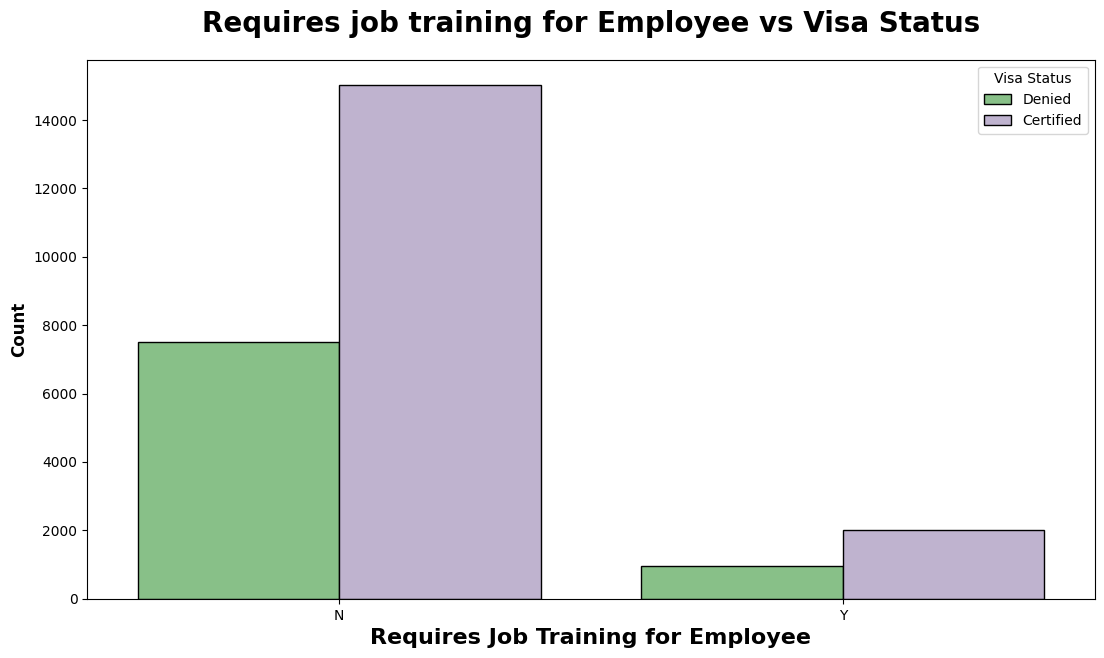

In [75]:
plt.subplots(figsize=(13,7))
sns.countplot(x="requires_job_training",hue="case_status", data=df, ec= "black",palette="Accent")
plt.title("Requires job training for Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

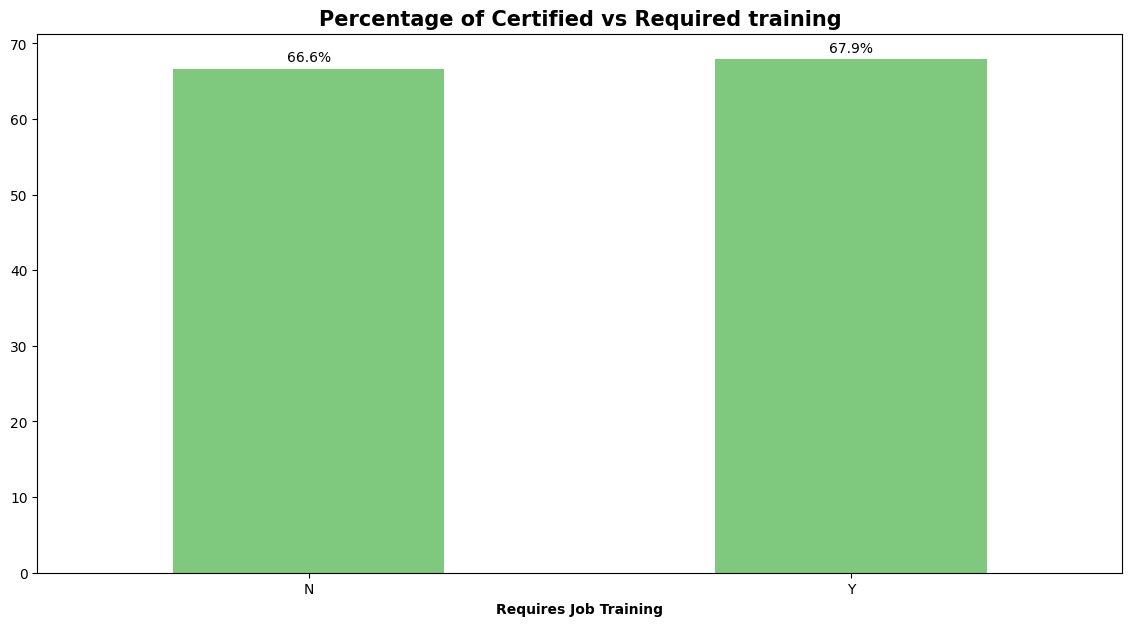

In [76]:
# 1. Calculate the percentage
percentages = (new_df['case_status'] == 'Certified').groupby(new_df['requires_job_training']).mean() * 100

# 2. Plot the bar chart
ax = percentages.plot(kind='bar', figsize=(14, 7), colormap='Accent')

# 3. Add labels automatically 
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# 4. Clean up titles and labels
plt.title("Percentage of Certified vs Required training", fontsize=15, fontweight='bold')
plt.xlabel('Requires Job Training', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### Insight
* If employee requires job training and it doesn't have any effect on Visa status.
* 88% of applicant don't require job training.
63% of people who doesnt want job training got certified.
* For employees who require job training 67% of people get certified.
* As we checked in Chi-Squared test this feature doesn't have much impact on target variable, which is confirmed by above plot.

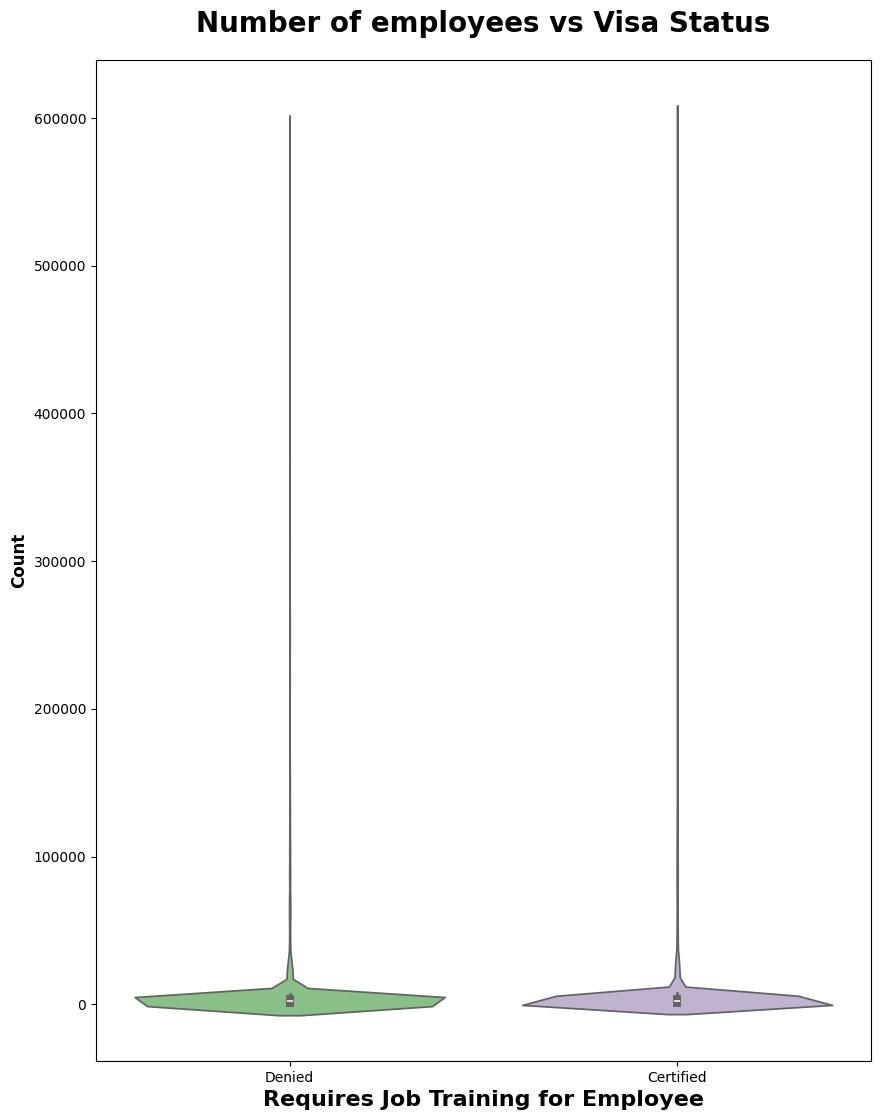

In [77]:
# Does Number of employees of employer has any impact on Visa status?
plt.subplots(figsize=(10,13))
sns.violinplot(x="case_status",y='no_of_employees', data=df, palette="Accent")
plt.title("Number of employees vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Requires Job Training for Employee", weight="bold", fontsize=16)
plt.ylim()
plt.show()

### Insights
* The distrubution of both is similar. But there are outliers in both the classes which need to be handled.

In [78]:
# Wages and its impact on Visa status
df.groupby('unit_of_wage')['case_status'].value_counts(normalize=True)

unit_of_wage  case_status
Hour          Denied         0.653686
              Certified      0.346314
Month         Certified      0.617978
              Denied         0.382022
Week          Certified      0.621324
              Denied         0.378676
Year          Certified      0.698850
              Denied         0.301150
Name: proportion, dtype: float64

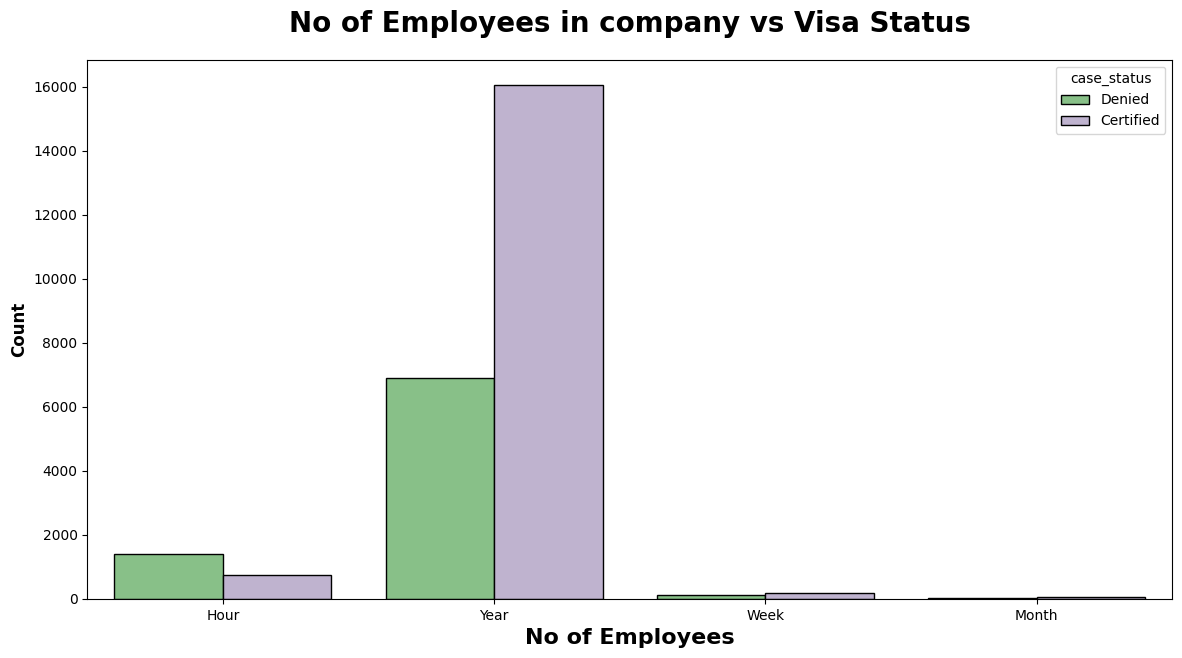

In [79]:
plt.subplots(figsize=(14,7))
sns.countplot(x="unit_of_wage",hue="case_status", data=df,ec='k', palette='Accent')
plt.title("No of Employees in company vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("No of Employees", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

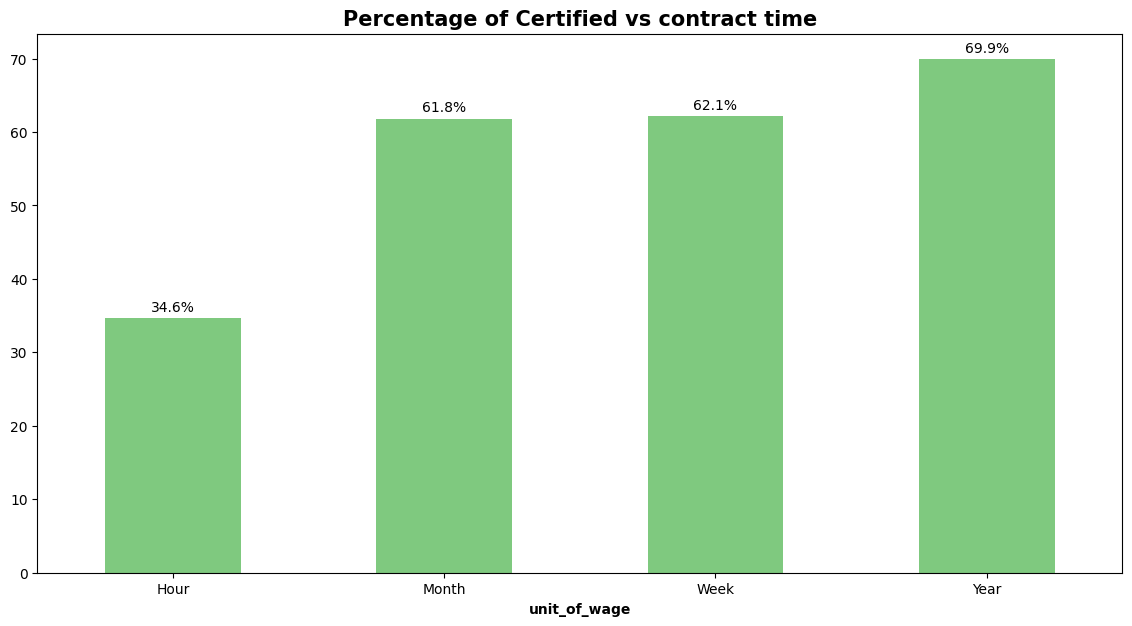

In [80]:
# 1. Calculate the percentage
percentages = (new_df['case_status'] == 'Certified').groupby(new_df['unit_of_wage']).mean() * 100

# 2. Plot the bar chart
ax = percentages.plot(kind='bar', figsize=(14, 7), colormap='Accent')

# 3. Add labels automatically 
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# 4. Clean up titles and labels
plt.title("Percentage of Certified vs contract time", fontsize=15, fontweight='bold')
plt.xlabel('unit_of_wage', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

### Insight
* For employees who applied for hourly pay 65% of them were denied.
* Yearly unit wage application were accepted for 69% and denied for 31% of the time.
* There is a higher chance of yearly contract than other and immediately followed by week and month.

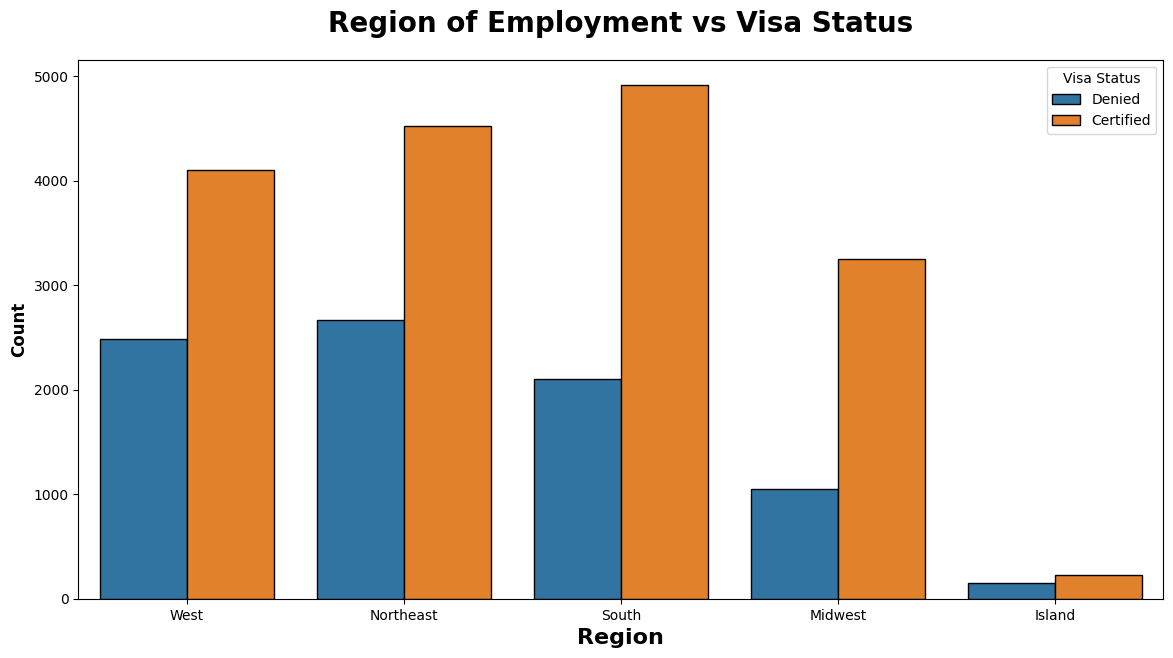

In [81]:
# Does Region of employment has impact on Visa status ?
plt.subplots(figsize=(14,7))
sns.countplot(x="region_of_employment",hue="case_status", data=df,ec='k')
plt.title("Region of Employment vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

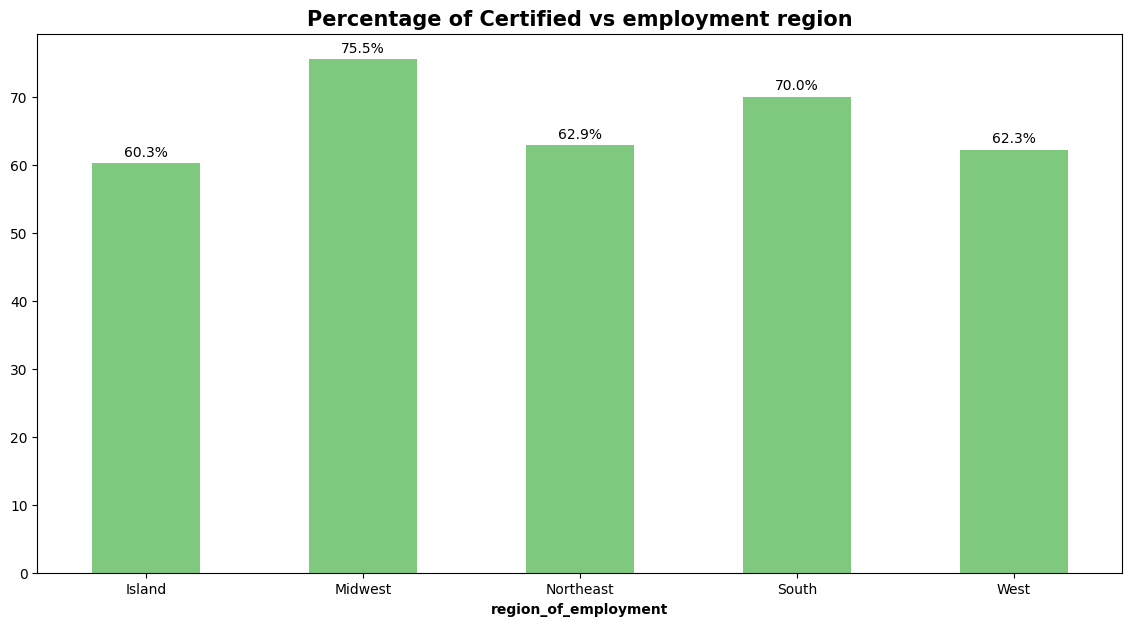

In [82]:
# 1. Calculate the percentage
percentages = (new_df['case_status'] == 'Certified').groupby(new_df['region_of_employment']).mean() * 100

# 2. Plot the bar chart
ax = percentages.plot(kind='bar', figsize=(14, 7), colormap='Accent')

# 3. Add labels automatically 
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

# 4. Clean up titles and labels
plt.title("Percentage of Certified vs employment region", fontsize=15, fontweight='bold')
plt.xlabel('region_of_employment', fontweight='bold')
plt.xticks(rotation=0) 
plt.show()

### Insight
* As per chart all the region have very similar pattern of getting Visa certified and Denied.
* There is a slight edge for midwest followed by South region

In [83]:
# Does Prevailing wage has any impact on Visa status ?
df.groupby('prevailing_wage').case_status.value_counts()

prevailing_wage  case_status
2.1367           Certified      1
2.9561           Denied         1
3.0031           Denied         1
3.3188           Denied         1
3.4889           Certified      1
                               ..
311734.4900      Certified      1
314156.0600      Certified      1
315497.6000      Certified      1
318446.0500      Certified      1
319210.2700      Denied         1
Name: count, Length: 25462, dtype: int64

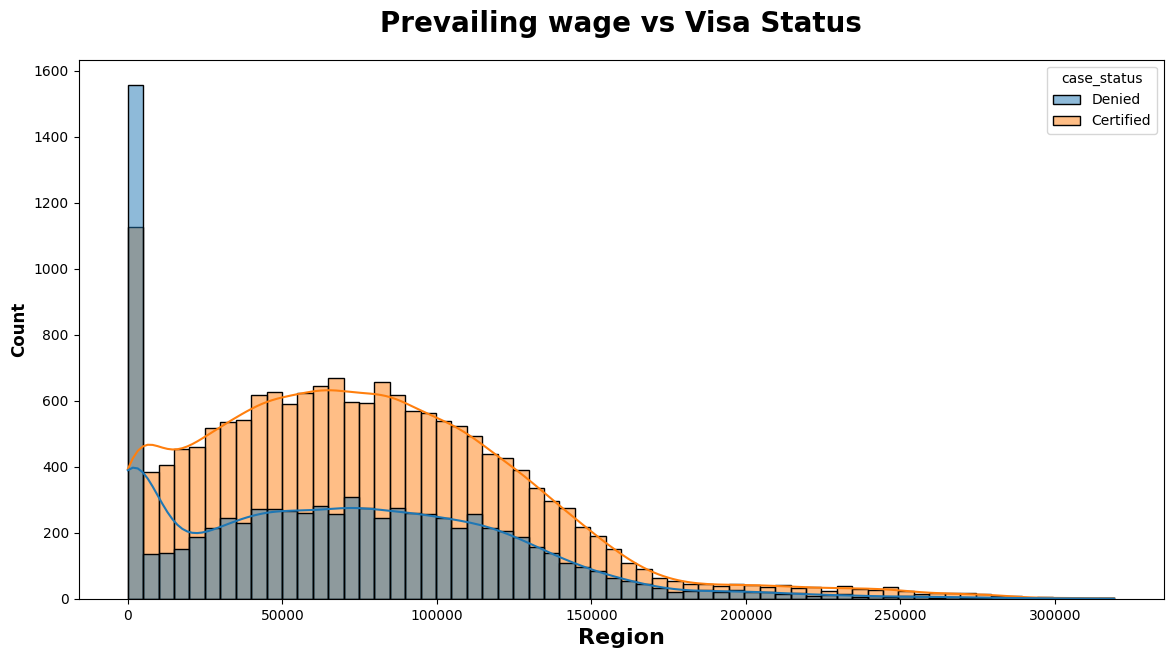

In [84]:
plt.subplots(figsize=(14,7))
sns.histplot(x="prevailing_wage",hue="case_status", data=df, kde=True)
plt.title("Prevailing wage vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Region", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()

In [85]:
# Prevailing wage based on Education
print('Average Prevailing wage based on Employee education')
df.groupby('education_of_employee')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Employee education


,prevailing_wage
education_of_employee,
Master's,78843.057843
Bachelor's,73405.443735
High School,71582.147756
Doctorate,64561.076657


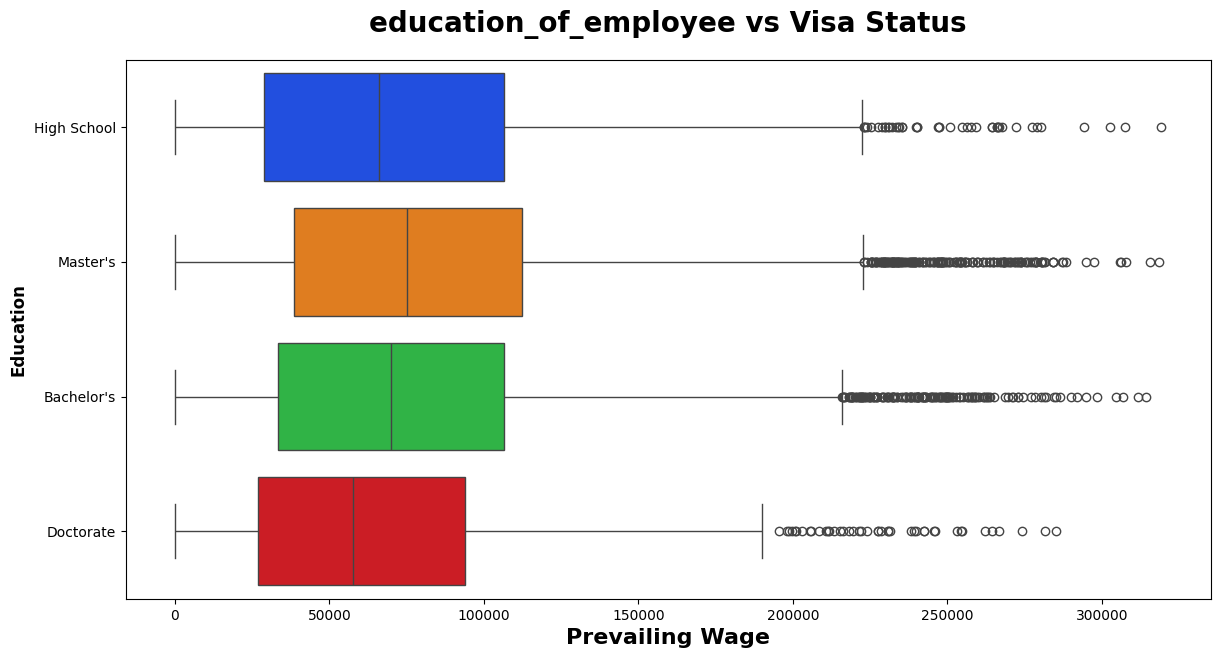

In [86]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="education_of_employee",x = "prevailing_wage", data=df,palette='bright')
plt.title("education_of_employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("Education", weight="bold", fontsize=12)
plt.show()

### Insight
* Based on the above table and charts its seen that applicant with Master's education has higher average prevailing wages.
* Master's education applicants have median salary of $78.8k, which approximately 20% higher than Doctorate's average wage, which is strange.

In [87]:
# Prevailing wage based on Job experience
print('Median Prevailing wage based on Job experience')
df.groupby('has_job_experience')['prevailing_wage'].median().to_frame().sort_values(by='prevailing_wage',ascending=False)

Median Prevailing wage based on Job experience


,prevailing_wage
has_job_experience,
N,72602.290
Y,69033.665


In [88]:
# Prevailing wage based on Continent
print('Average Prevailing wage based on Continent')
df.groupby('continent')['prevailing_wage'].mean().to_frame().sort_values(by='prevailing_wage',ascending=False)

Average Prevailing wage based on Continent


,prevailing_wage
continent,
Asia,79543.021780
Africa,77425.923450
Oceania,75994.276719
North America,68066.319257
South America,60209.575314
Europe,59842.925899


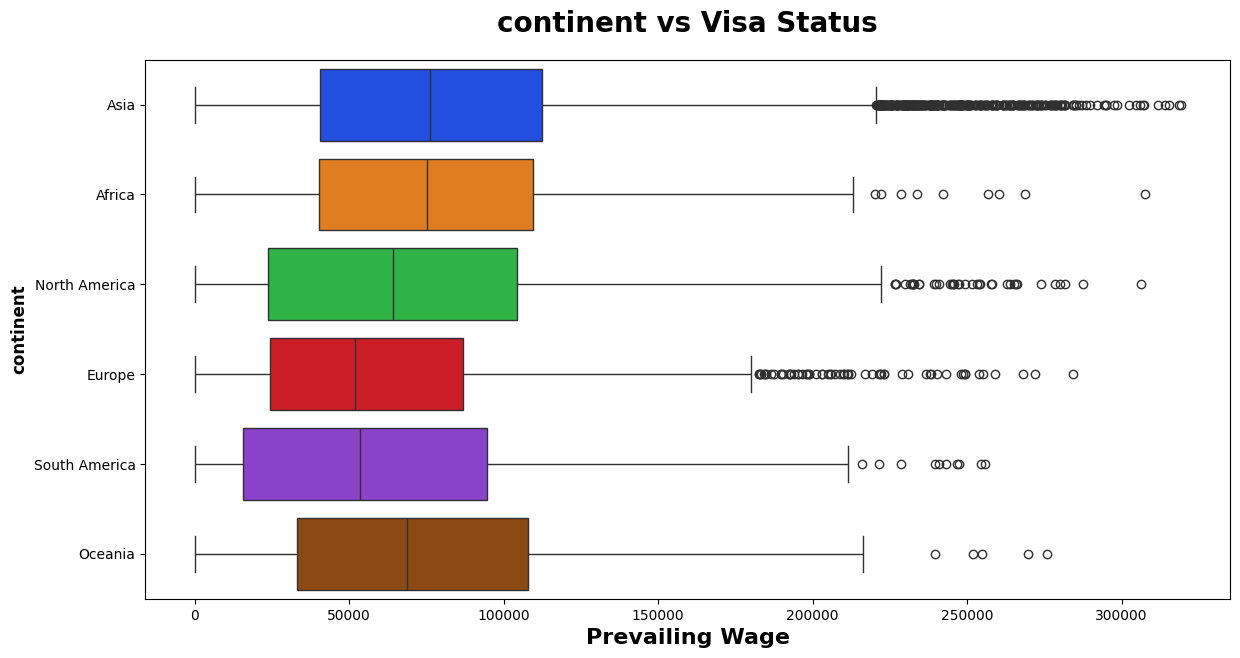

In [89]:
plt.subplots(figsize=(14,7))
sns.boxplot(y="continent",x = "prevailing_wage", data=df,palette='bright')
plt.title("continent vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("Prevailing Wage", weight="bold", fontsize=16)
plt.ylabel("continent", weight="bold", fontsize=12)
plt.show()


* Average salary of people from Asia is higher than other continents.

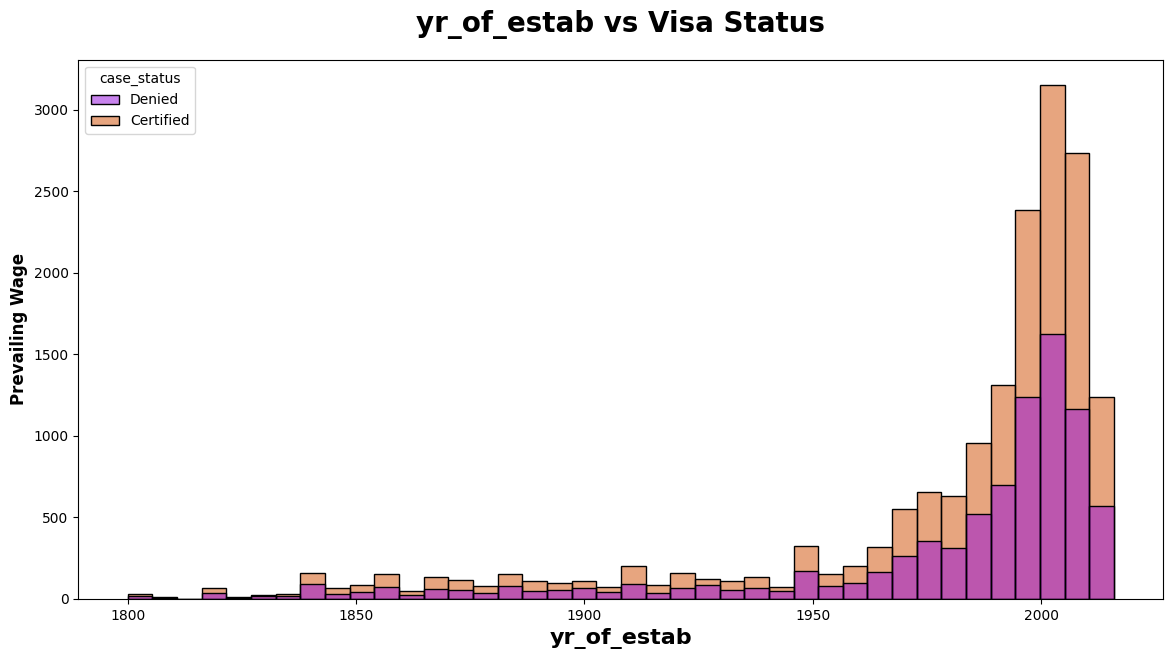

In [90]:
# Year of Establishment
plt.subplots(figsize=(14,7))
sns.histplot(x = "yr_of_estab", data=df,palette='gnuplot', bins=40, hue='case_status')
plt.title("yr_of_estab vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.xlabel("yr_of_estab", weight="bold", fontsize=16)
plt.ylabel("Prevailing Wage", weight="bold", fontsize=12)
plt.show()

### Insight
* Each bins consists of 5 years.
* Many companies were established after year 2000.
* The most company establishment happened in year 2000-2005.

### Final Report
* `case_id` column can be dropped as it is an ID.
* `requires_job_training` column can be dropped as it doesn't have much impact on target variable, Proved in visualization and chi2 test.
* `no_of_employees`, prevailing_wage columns have outllier which should be handled.
* `continent` columns has few unique values with very less count, which can be made as others
* Target column `case_status` is imbalanced can be handled before model building.